In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scienceplots

plt.style.use(['science', 'nature'])

In [10]:
# Load genome statistics data
df_statistics = pd.read_csv("../../data/processed_data/dataset_information/genomes_info_with_partitions.csv")
df_statistics = df_statistics.rename(columns={"Unnamed: 0":"accession"})

In [11]:
# Colorblind-friendly palette (Tol's bright)
colors_dict = {
    'train': '#44AA99',   # Teal
    'val': '#AA4499',     # Rose
    'test': '#63A31A',    # Coral (more visible than sand)
    'hist': '#332288'     # Deep indigo
}


colors_dict = {
    'train': "#3BC552",   # Teal
    'val': '#4A90D9',     # Rose
    'test': '#C88B3A',    # Coral (more visible than sand)
    'hist': "#030050"     # Deep indigo
}

# Plots of coding percentage

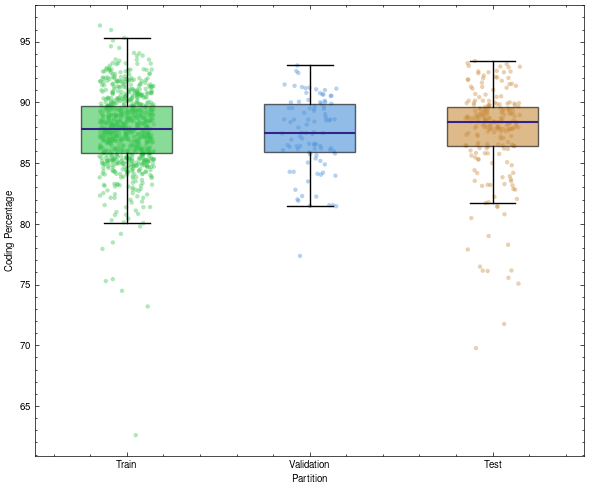


Summary Statistics by Partition:
           count       mean       std    min     25%    50%     75%    max
partition                                                                 
test       215.0  87.576186  3.849410  69.77  86.445  88.42  89.635  93.41
train      813.0  87.710037  3.077385  62.60  85.810  87.79  89.710  96.34
val         97.0  87.446701  3.025209  77.36  85.920  87.51  89.900  93.05


In [12]:
# Boxplot + strip (jittered points)
fig, ax = plt.subplots(figsize=(6, 5))

partition_order = ['train', 'val', 'test']
partition_labels = ['Train', 'Validation', 'Test']
positions = [1, 2, 3]

# Draw boxplots
data_by_partition = [df_statistics[df_statistics['partition'] == p]['coding_percentage'].values 
                     for p in partition_order]

bp = ax.boxplot(data_by_partition, positions=positions, widths=0.5, patch_artist=True,
                showfliers=False)

for i, (patch, partition) in enumerate(zip(bp['boxes'], partition_order)):
    patch.set_facecolor(colors_dict[partition])
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('#332288')
    median.set_linewidth(1.5)

# Add jittered points
for i, (partition, pos) in enumerate(zip(partition_order, positions)):
    data = df_statistics[df_statistics['partition'] == partition]['coding_percentage']
    jitter = np.random.uniform(-0.15, 0.15, size=len(data))
    ax.scatter(pos + jitter, data, alpha=0.4, s=10, color=colors_dict[partition], edgecolor='none')

ax.set_xticks(positions)
ax.set_xticklabels(partition_labels)
ax.set_xlabel('Partition')
ax.set_ylabel('Coding Percentage')

plt.tight_layout()
#plt.savefig('coding_percentage_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics by partition
print("\nSummary Statistics by Partition:")
print(df_statistics.groupby('partition')['coding_percentage'].describe())

# Plot genome length

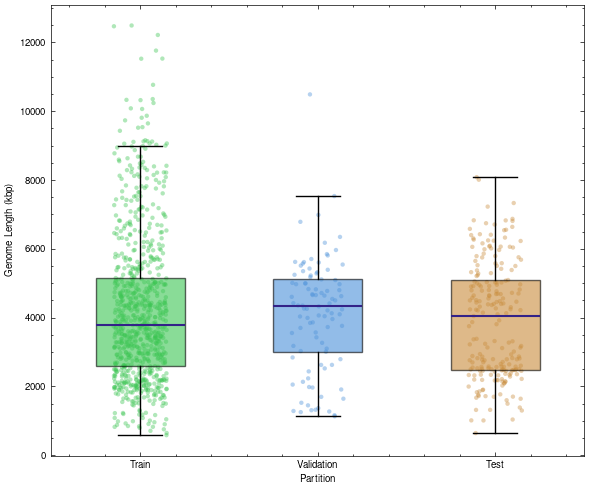


Summary Statistics by Partition:
           count         mean          std     min     25%     50%     75%  \
partition                                                                    
test       215.0  3895.511628  1669.290444   641.0  2473.0  4042.0  5080.5   
train      813.0  4215.261993  2156.957274   580.0  2600.0  3788.0  5163.0   
val         97.0  4081.865979  1644.985028  1130.0  3006.0  4324.0  5107.0   

               max  
partition           
test        8080.0  
train      12489.0  
val        10486.0  


In [13]:
# Boxplot + strip (jittered points)
fig, ax = plt.subplots(figsize=(6, 5))

partition_order = ['train', 'val', 'test']
partition_labels = ['Train', 'Validation', 'Test']
positions = [1, 2, 3]

# Draw boxplots
data_by_partition = [df_statistics[df_statistics['partition'] == p]['genome_length_kb'].values 
                     for p in partition_order]

bp = ax.boxplot(data_by_partition, positions=positions, widths=0.5, patch_artist=True,
                showfliers=False)

for i, (patch, partition) in enumerate(zip(bp['boxes'], partition_order)):
    patch.set_facecolor(colors_dict[partition])
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('#332288')
    median.set_linewidth(1.5)

# Add jittered points
for i, (partition, pos) in enumerate(zip(partition_order, positions)):
    data = df_statistics[df_statistics['partition'] == partition]['genome_length_kb']
    jitter = np.random.uniform(-0.15, 0.15, size=len(data))
    ax.scatter(pos + jitter, data, alpha=0.4, s=10, color=colors_dict[partition], edgecolor='none')

ax.set_xticks(positions)
ax.set_xticklabels(partition_labels)
ax.set_xlabel('Partition')
ax.set_ylabel('Genome Length (kbp)')

plt.tight_layout()
#plt.savefig('genome_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics by partition
print("\nSummary Statistics by Partition:")
print(df_statistics.groupby('partition')['genome_length_kb'].describe())

# Plot GC-content

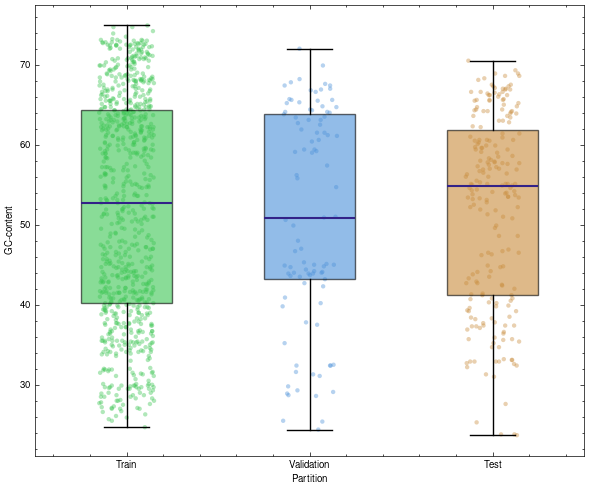


Summary Statistics by Partition:
           count       mean        std   min   25%   50%   75%   max
partition                                                           
test       215.0  52.039535  11.864184  23.7  41.2  54.9  61.8  70.5
train      813.0  51.966913  13.801471  24.7  40.2  52.7  64.3  74.9
val         97.0  51.097938  13.442733  24.4  43.2  50.9  63.8  72.0


In [14]:
# Boxplot + strip (jittered points)
fig, ax = plt.subplots(figsize=(6, 5))

partition_order = ['train', 'val', 'test']
partition_labels = ['Train', 'Validation', 'Test']
positions = [1, 2, 3]

# Draw boxplots
data_by_partition = [df_statistics[df_statistics['partition'] == p]['gc_content'].values 
                     for p in partition_order]

bp = ax.boxplot(data_by_partition, positions=positions, widths=0.5, patch_artist=True,
                showfliers=False)

for i, (patch, partition) in enumerate(zip(bp['boxes'], partition_order)):
    patch.set_facecolor(colors_dict[partition])
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('#332288')
    median.set_linewidth(1.5)

# Add jittered points
for i, (partition, pos) in enumerate(zip(partition_order, positions)):
    data = df_statistics[df_statistics['partition'] == partition]['gc_content']
    jitter = np.random.uniform(-0.15, 0.15, size=len(data))
    ax.scatter(pos + jitter, data, alpha=0.4, s=10, color=colors_dict[partition], edgecolor='none')

ax.set_xticks(positions)
ax.set_xticklabels(partition_labels)
ax.set_xlabel('Partition')
ax.set_ylabel('GC-content')

plt.tight_layout()
#plt.savefig('gc_content_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics by partition
print("\nSummary Statistics by Partition:")
print(df_statistics.groupby('partition')['gc_content'].describe())

# Plot median CDS length

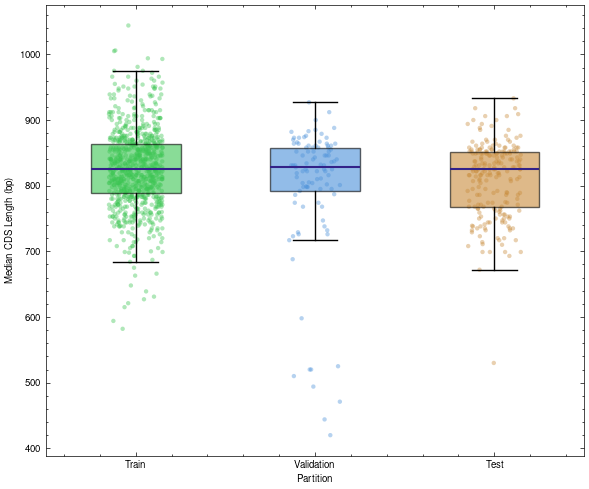


Summary Statistics by Partition:
           count        mean         std    min    25%    50%    75%     max
partition                                                                   
test       215.0  810.176744   56.353909  530.0  768.0  825.0  851.0   933.0
train      813.0  825.467405   60.520712  582.0  789.0  825.0  864.0  1044.0
val         97.0  796.175258  106.377767  420.0  792.0  828.0  858.0   927.0


In [15]:
# Boxplot + strip (jittered points)
fig, ax = plt.subplots(figsize=(6, 5))

partition_order = ['train', 'val', 'test']
partition_labels = ['Train', 'Validation', 'Test']
positions = [1, 2, 3]

# Draw boxplots
data_by_partition = [df_statistics[df_statistics['partition'] == p]['cds_median_length'].values 
                     for p in partition_order]

bp = ax.boxplot(data_by_partition, positions=positions, widths=0.5, patch_artist=True,
                showfliers=False)

for i, (patch, partition) in enumerate(zip(bp['boxes'], partition_order)):
    patch.set_facecolor(colors_dict[partition])
    patch.set_alpha(0.6)

for median in bp['medians']:
    median.set_color('#332288')
    median.set_linewidth(1.5)

# Add jittered points
for i, (partition, pos) in enumerate(zip(partition_order, positions)):
    data = df_statistics[df_statistics['partition'] == partition]['cds_median_length']
    jitter = np.random.uniform(-0.15, 0.15, size=len(data))
    ax.scatter(pos + jitter, data, alpha=0.4, s=10, color=colors_dict[partition], edgecolor='none')

ax.set_xticks(positions)
ax.set_xticklabels(partition_labels)
ax.set_xlabel('Partition')
ax.set_ylabel('Median CDS Length (bp)')

plt.tight_layout()
#plt.savefig('median_cds_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics by partition
print("\nSummary Statistics by Partition:")
print(df_statistics.groupby('partition')['cds_median_length'].describe())

# Combined figure

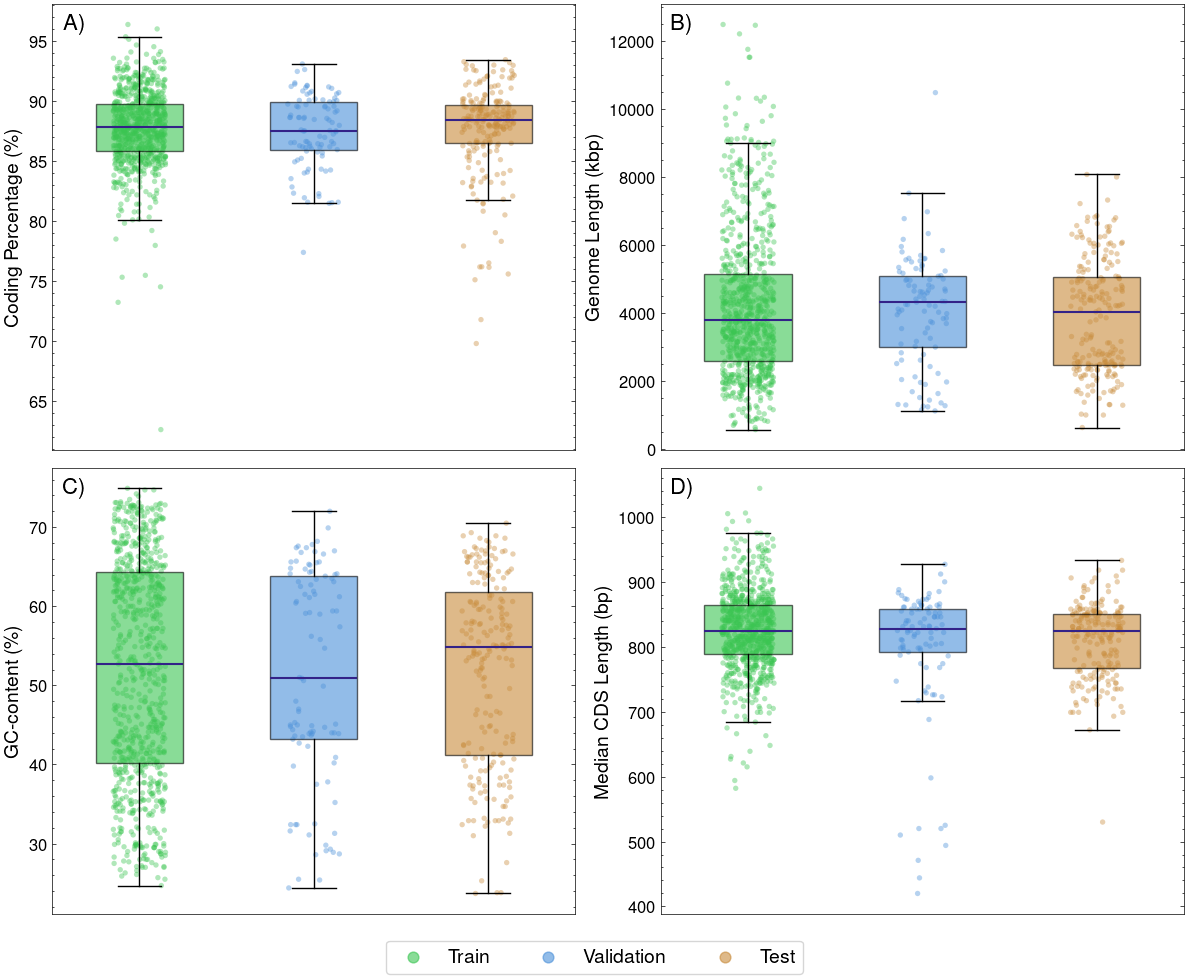

In [16]:
# Combined figure with all 4 plots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

partition_order = ['train', 'val', 'test']
partition_labels = {'train': 'Train', 'val': 'Validation', 'test': 'Test'}
positions = [1, 2, 3]

# Data columns and labels for each subplot
plot_configs = [
    ('coding_percentage', r'Coding Percentage (\%)', 'A)'),
    ('genome_length_kb', 'Genome Length (kbp)', 'B)'),
    ('gc_content', r'GC-content (\%)', 'C)'),
    ('cds_median_length', 'Median CDS Length (bp)', 'D)')
]

# Create each subplot
for ax, (column, ylabel, panel_label) in zip(axes.flatten(), plot_configs):
    # Draw boxplots
    data_by_partition = [df_statistics[df_statistics['partition'] == p][column].values 
                         for p in partition_order]
    
    bp = ax.boxplot(data_by_partition, positions=positions, widths=0.5, patch_artist=True,
                    showfliers=False)
    
    for i, (patch, partition) in enumerate(zip(bp['boxes'], partition_order)):
        patch.set_facecolor(colors_dict[partition])
        patch.set_alpha(0.6)
    
    for median in bp['medians']:
        median.set_color('#332288')
        median.set_linewidth(1.5)
    
    # Add jittered points
    scatter_handles = []
    for i, (partition, pos) in enumerate(zip(partition_order, positions)):
        data = df_statistics[df_statistics['partition'] == partition][column]
        jitter = np.random.uniform(-0.15, 0.15, size=len(data))
        sc = ax.scatter(pos + jitter, data, alpha=0.4, s=15, color=colors_dict[partition], 
                       edgecolor='none', label=partition_labels[partition])
        scatter_handles.append(sc)
    
    # Remove x-axis labels (will use shared legend instead)
    ax.set_xticks([])
    ax.set_ylabel(ylabel, fontsize=14)
    ax.tick_params(axis='y', labelsize=12)
    
    # Add panel label
    ax.text(0.02, 0.98, panel_label, transform=ax.transAxes, fontsize=16, 
            fontweight='bold', va='top')

# Create shared legend
handles = [plt.scatter([], [], color=colors_dict[p], s=60, alpha=0.6, label=partition_labels[p]) 
           for p in partition_order]
fig.legend(handles=handles, loc='lower center', ncol=3, fontsize=14, 
           frameon=True, bbox_to_anchor=(0.5, 0.01))

plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
plt.savefig('../../illustrations/genome_statistics/genome_statistics_combined.png', dpi=300, bbox_inches='tight')
plt.show()